# 1). Import libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

# 2). Load dataset

In [2]:
df=pd.read_csv("/workspaces/Modelling_Credit_Defaults-Logistic_Regression-/data/lending_club_loan_data/clean_data.csv")
df.head()

,loan_amnt,term,int_rate,installment,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,...,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies
0,5000,36 months,10.65,162.87,NaN,10+ years,RENT,24000.0,Verified,0,...,27.65,0,1985-01-01,1,3,0,13648,83.7,9,0.0
1,2500,60 months,15.27,59.83,Ryder,< 1 year,RENT,30000.0,Source Verified,1,...,1.00,0,1999-04-01,5,3,0,1687,9.4,4,0.0
2,2400,36 months,15.96,84.33,NaN,10+ years,RENT,12252.0,Not Verified,0,...,8.72,0,2001-11-01,2,2,0,2956,98.5,10,0.0
3,10000,36 months,13.49,339.31,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,0,...,20.00,0,1996-02-01,1,10,0,5598,21.0,37,0.0
4,5000,36 months,7.90,156.46,Veolia Transportaton,3 years,RENT,36000.0,Source Verified,0,...,11.20,0,2004-11-01,3,9,0,7963,28.3,12,0.0


# 3). Explore

In [3]:
# Multicolinearity
corr_matrix=df.select_dtypes("number").dropna().corr()
corr_matrix


,loan_amnt,int_rate,installment,annual_inc,loan_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies
loan_amnt,1.000000,0.302044,0.931765,0.272907,0.058097,0.061204,-0.032930,0.011097,0.177686,-0.050823,0.316515,0.062184,0.256280,-0.036150
int_rate,0.302044,1.000000,0.278414,0.050613,0.212140,0.106420,0.159123,0.136296,0.007190,0.098574,0.095592,0.466189,-0.047099,0.083206
installment,0.931765,0.278414,1.000000,0.272342,0.024433,0.051466,-0.021129,0.008683,0.173433,-0.046202,0.312378,0.092546,0.230596,-0.033520
annual_inc,0.272907,0.050613,0.272342,1.000000,-0.041882,-0.121373,0.022221,0.034044,0.158758,-0.017995,0.276861,0.017664,0.237443,-0.016280
loan_status,0.058097,0.212140,0.024433,-0.041882,1.000000,0.044871,0.018733,0.070603,-0.008543,0.051503,0.006153,0.100299,-0.022116,0.048028
dti,0.061204,0.106420,0.051466,-0.121373,0.044871,1.000000,-0.033890,0.002368,0.289219,-0.005452,0.228576,0.276559,0.227615,0.005686
delinq_2yrs,-0.032930,0.159123,-0.021129,0.022221,0.018733,-0.033890,1.000000,0.008833,0.012584,0.008299,-0.056367,-0.043964,0.067955,0.003456
inq_last_6mths,0.011097,0.136296,0.008683,0.034044,0.070603,0.002368,0.008833,1.000000,0.093894,0.023587,-0.024069,-0.069657,0.114602,0.015511
open_acc,0.177686,0.007190,0.173433,0.158758,-0.008543,0.289219,0.012584,0.093894,1.000000,0.000616,0.286846,-0.089969,0.686532,0.005700
pub_rec,-0.050823,0.098574,-0.046202,-0.017995,0.051503,-0.005452,0.008299,0.023587,0.000616,1.000000,-0.061131,0.058278,-0.023981,0.846057


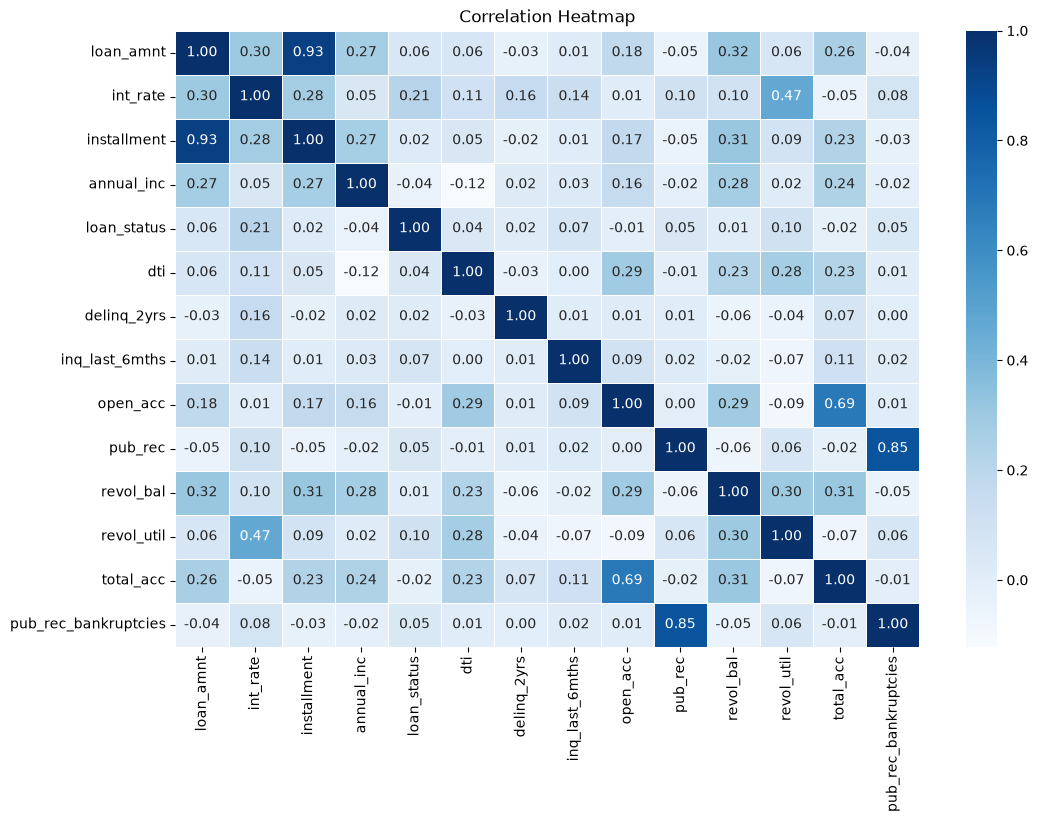

In [4]:
fg, ax=plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, ax=ax, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Insights
- The correlation matrix reveals that the dataset contain strong relationships among some select features loan_amnt and installment are almost perfectly correlated (0.93), suggesting they carry nearly identical information.
- pub_rec and pub_rec_bankruptcies also show very high correlation (0.85), meaning one is largely a subset of the other.
- Additionally, open_acc and total_acc show moderate-to-high correlation (0.69), further indicating some redundancy among credit history variables. 
- Most other features exhibit weak to moderate correlations with the target variable loan_status, with interest rate showing the strongest individual relationship (0.21), implying that default risk is not driven by a single dominant factor but rather a combination of variables.

Based on these findings, we will reduce redundancy by dropping highly collinear features, specifically removing installment and pub_rec_bankruptcies, while retaining the more informative variables.

### a). Target variable (Loan Status)

In [5]:
class_balance=df.loan_status.value_counts(normalize=True)
class_balance

loan_status
0    0.854136
1    0.145864
Name: proportion, dtype: float64

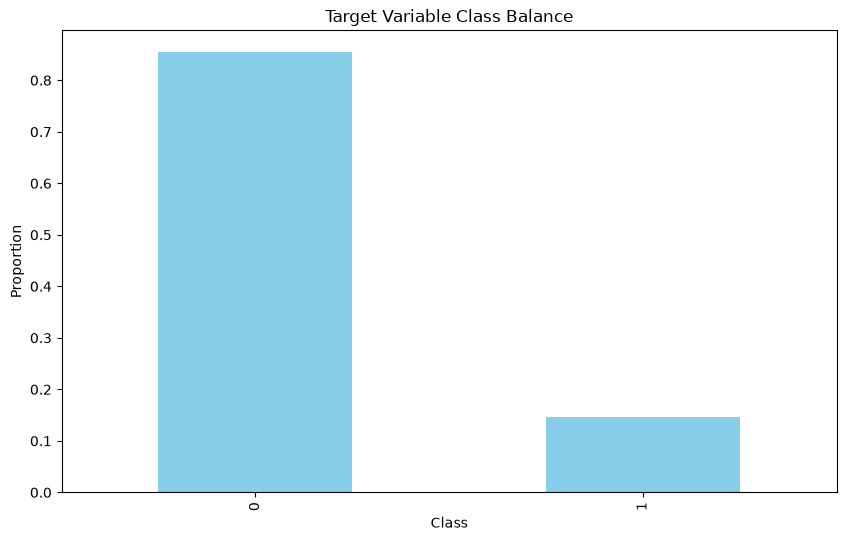

In [6]:
fig, ax=plt.subplots(figsize=(10,6))
class_balance.plot(kind="bar", ax=ax,
                   xlabel="Class", 
                   ylabel="Proportion",
                   title="Target Variable Class Balance",
                   color="skyblue")
plt.show();


The target variable exhibits a noticeable class imbalance, with approximately 85.4% of loans classified as Fully Paid (0) and only 14.6% classified as Charged Off (1). This indicates that defaults are relatively uncommon compared to successful loan repayments. While this level of imbalance is not extreme, it is significant enough that model evaluation should not rely solely on accuracy, since a model that predicts every loan as fully paid would still achieve about 85% accuracy. Therefore, performance metrics such as precision, recall, F1-score, ROC-AUC, should be considered when evaluating models. The imbalance should also be kept in mind during model development, as some algorithms may become biased toward the majority class and fail to identify defaulted loans effectively.


In [7]:
df.loan_amnt.describe()

count    38577.000000
mean     11047.025430
std       7348.441646
min        500.000000
25%       5300.000000
50%       9600.000000
75%      15000.000000
max      35000.000000
Name: loan_amnt, dtype: float64

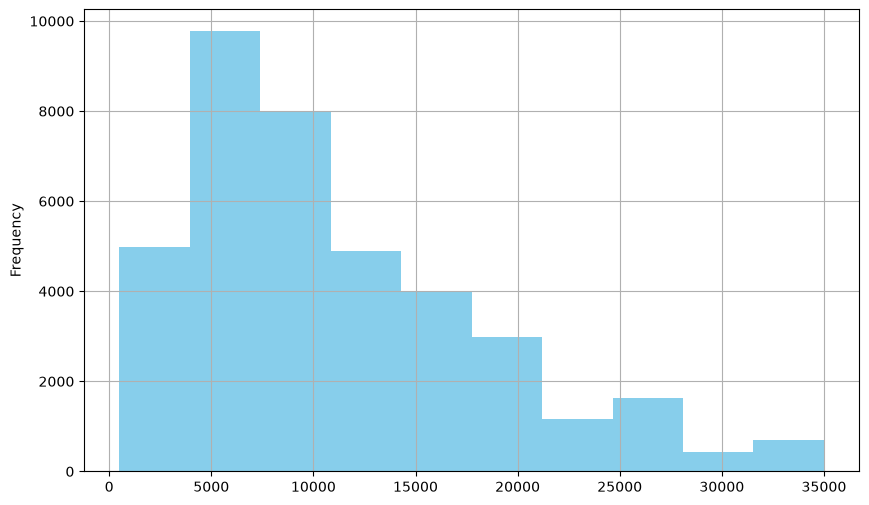

In [8]:
fig, ax=plt.subplots(figsize=(10,6))
df["loan_amnt"].plot(kind="hist", ax=ax, color="skyblue")
plt.grid()

- The average loan amount is approximately $11,047, with a standard deviation of $7,348, suggesting substantial variability in the amounts borrowed. Loan amounts range from a minimum of $500 to a maximum of $35,000, indicating a wide spread of loan sizes. The median loan amount is $9,600, which is lower than the mean. 
- There is a slight right-skew in the distribution, some larger loans pull the average upward. 
- 25 percent of loans are $5,300 or less, while 75% are $15,000 or less, meaning that half of all loans fall between $5,300 and $15,000. 
- Overall, the distribution suggests that most borrowers take out relatively modest loans, although a smaller number of larger loans contribute to the higher average loan amount.